In [6]:
from langgraph.graph import StateGraph , START , END 
from typing import TypedDict 


In [11]:
## creating an state

class bmi_state(TypedDict):
    weight_kg:float
    height_m:float
    bmi :float
    category:str



In [12]:
def calculate_bmi(state:bmi_state)->bmi_state:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)

    return state



In [20]:
def check_category(state:bmi_state)->bmi_state:
    bmi=state['bmi']

    if bmi < 10:
        state['category']="under weigh"
    elif bmi > 10 and bmi<20 :
        state['category']="good"
    else :
        state['category']="over weight"
    
    return state

    

In [21]:
## craeting graph 

graph=StateGraph(bmi_state)

## generating ndoe 

graph.add_node("bmi_calculate_node",calculate_bmi)
graph.add_node("category_node",check_category)

## adding edges 

graph.add_edge(START,"bmi_calculate_node")
graph.add_edge("bmi_calculate_node","category_node")
graph.add_edge("category_node",END)


In [22]:
## compiling then graph 

workflow=graph.compile()

In [29]:
##executinbg the compiled graph --> it requires initial state first 

initial_state={'weight_kg':10,'height_m':1.53}

output_state=workflow.invoke(initial_state)


In [30]:
## printing then output state 

print(output_state)

{'weight_kg': 10, 'height_m': 1.53, 'bmi': 4.27, 'category': 'under weigh'}


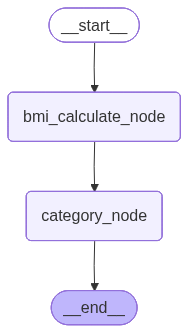

In [32]:
 from IPython.display import Image
 Image(workflow.get_graph().draw_mermaid_png())